In [1]:
import csv
import nibabel as nib
import matplotlib.pyplot as plt
import random
import torch
import os
import numpy as np
from model1_old import CNN_3D,NiiDataset,MultiModalTransformer,NeuralNet
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import nibabel as nib
import shutil
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import math
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
CUDA_LAUNCH_BLOCKING=1

In [2]:
path_existence = []
data_prodromal=[]
data_swedd=[]
data_control=[]
data_PD = []
count_control = 0
count_PD = 0
count_swedd = 0
count_prodromal = 0
with open('PD1.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader)  
    for row in csv_reader:
        path = 'PD/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_PD=count_PD+1
            data_PD.append(row)
            
with open('control.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'Control/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_control=count_control+1
            data_control.append(row)
            
with open('swedd.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'SWEDD/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_swedd=count_swedd+1
            data_swedd.append(row)

with open('prodromal.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'Prodromal/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_prodromal=count_prodromal+1
            data_prodromal.append(row)
print(count_PD) 
print(count_control) 
print(count_swedd) 
print(count_prodromal)

125
132
72
80


In [3]:
PD_arrays=[]
replace_dict = {'F': '0','M':'1','Normal':'0','Slight':'1','Mild':'2','Moderate':'3','Severe':'4','T1-anatomical':'1','Processed':'1', 
               'BL':'0','V04':'1','V06':'2','V06':'3','V08':'4','V10':'5','NiFTI':'1','':'0','No':'0','Yes':'1','Stage 1':'1','Stage 2':'2','Stage 3':'3','Stage 4':'4'
               ,'On':'1','Off':'0','Stage 0':'0'}
for i in data_PD:
    j= i[21:]
    j= [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    PD_array = np.array(num_list)
    PD_arrays.append(PD_array)
PD_array = np.vstack(PD_arrays)

In [4]:
control_arrays = []
for i in data_control:
    j = i[21:]
    j = [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    control_array = np.array(num_list)
    control_arrays.append(control_array)
control_array = np.vstack(control_arrays)

In [5]:
swedd_arrays = []
for i in data_swedd:
    j = i[21:]
    j = [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    swedd_array = np.array(num_list)
    swedd_arrays.append(swedd_array)
swedd_array = np.vstack(swedd_arrays)

In [6]:
prodromal_arrays = []
for i in data_prodromal:
    j = i[21:]
    j = [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    prodromal_array = np.array(num_list)
    prodromal_arrays.append(prodromal_array)
prodromal_array = np.vstack(prodromal_arrays)

In [7]:
#线性 48--->16--->1  两个线性层
pd_tensor = torch.from_numpy(PD_array).float()
control_tensor = torch.from_numpy(control_array).float()
swedd_tensor = torch.from_numpy(swedd_array).float()
prodromal_tensor = torch.from_numpy(prodromal_array).float()

linear_layer = nn.Linear(64, 32)
pd_tensor = linear_layer(pd_tensor)
control_tensor = linear_layer(control_tensor)
swedd_tensor = linear_layer(swedd_tensor)
prodromal_tensor = linear_layer(prodromal_tensor)

linear_layer = nn.Linear(32, 16)
pd_tensor = linear_layer(pd_tensor)
control_tensor = linear_layer(control_tensor)
swedd_tensor = linear_layer(swedd_tensor)
prodromal_tensor = linear_layer(prodromal_tensor)

linear_layer = nn.Linear(16, 1)
pd_tensor = linear_layer(pd_tensor)
control_tensor = linear_layer(control_tensor)
swedd_tensor = linear_layer(swedd_tensor)
prodromal_tensor = linear_layer(prodromal_tensor)

print('pd.shape--->', pd_tensor.shape)
print("control.shape--->", control_tensor.shape)
print('swedd.shape--->', swedd_tensor.shape)
print('prodromal.shape--->', prodromal_tensor.shape)

pd.shape---> torch.Size([125, 1])
control.shape---> torch.Size([132, 1])
swedd.shape---> torch.Size([72, 1])
prodromal.shape---> torch.Size([80, 1])


In [8]:
# 数据处理函数
def preprocess_data(data, replace_dict):
    processed_data = []
    for row in data:
        row = [replace_dict.get(item, item) for item in row]
        row = [float(item) if item.replace('.', '', 1).isdigit() else item for item in row]
        processed_data.append(row[4:22])
    return np.array(processed_data)

In [9]:
# 编码类别型变量
def encode_categorical(data, categorical_indices):
    encoded_data = data.copy()
    for idx in categorical_indices:
        le = LabelEncoder()
        encoded_data[:, idx] = le.fit_transform(encoded_data[:, idx])
    return encoded_data.astype(float)

In [10]:
pd_data = preprocess_data(data_PD, replace_dict)
control_data = preprocess_data(data_control, replace_dict)
swedd_data = preprocess_data(data_swedd, replace_dict)
prodromal_data = preprocess_data(data_prodromal, replace_dict)

categorical_indices = [2, 3, 4, 5]  # gender, education, hispanic, race, apoe
pd_EHR = encode_categorical(pd_data, categorical_indices)
control_EHR = encode_categorical(control_data, categorical_indices)
swedd_EHR = encode_categorical(swedd_data, categorical_indices)
prodromal_EHR = encode_categorical(prodromal_data, categorical_indices)

pd_EHR = torch.from_numpy(pd_EHR).float()
control_EHR = torch.from_numpy(control_EHR).float()
swedd_EHR = torch.from_numpy(swedd_EHR).float()
prodromal_EHR = torch.from_numpy(prodromal_EHR).float()

linear_layer = nn.Linear(18, 16)
control_EHR = linear_layer(control_EHR)
pd_EHR = linear_layer(pd_EHR)
swedd_EHR = linear_layer(swedd_EHR)
prodromal_EHR = linear_layer(prodromal_EHR)

linear_layer = nn.Linear(16, 1)
control_EHR = linear_layer(control_EHR)
pd_EHR = linear_layer(pd_EHR)
swedd_EHR = linear_layer(swedd_EHR)
prodromal_EHR = linear_layer(prodromal_EHR)

print('pd.EHR--->', pd_EHR.shape)
print('control.EHR--->', control_EHR.shape)
print('swedd.EHR--->', swedd_EHR.shape)
print('prodromal.EHR--->', prodromal_EHR.shape)
    

pd.EHR---> torch.Size([125, 1])
control.EHR---> torch.Size([132, 1])
swedd.EHR---> torch.Size([72, 1])
prodromal.EHR---> torch.Size([80, 1])


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [12]:
import os

# 根据csv中行生成各自的影像路径列表，只取存在的文件
pd_img_paths = [os.path.join('PD', row[1]) for row in data_PD if os.path.exists(os.path.join('PD', row[1]))]
control_img_paths = [os.path.join('Control', row[1]) for row in data_control if os.path.exists(os.path.join('Control', row[1]))]
swedd_img_paths = [os.path.join('SWEDD', row[1]) for row in data_swedd if os.path.exists(os.path.join('SWEDD', row[1]))]
prodromal_img_paths = [os.path.join('Prodromal', row[1]) for row in data_prodromal if os.path.exists(os.path.join('Prodromal', row[1]))]

print(f'PD 影像数量: {len(pd_img_paths)}')            # 应为125
print(f'Control 影像数量: {len(control_img_paths)}')  # 应为132
print(f'SWEDD 影像数量: {len(swedd_img_paths)}')      # 应为72
print(f'Prodromal 影像数量: {len(prodromal_img_paths)}')  # 应为80


PD 影像数量: 125
Control 影像数量: 132
SWEDD 影像数量: 72
Prodromal 影像数量: 80


In [13]:
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
nii = CNN_3D(num_class=1)
nii = nii.to(device)
batch_size = 16

# 1. PD组
dataset = NiiDataset(pd_img_paths)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    print('batch_data.shape:', batch_data.shape)  # 这一步很重要
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
PD_output = torch.cat(all_outputs, dim=0)
print('PD nii shape--->', PD_output.shape)

# 2. Control组
dataset = NiiDataset(control_img_paths)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    print('batch_data.shape:', batch_data.shape)  # 这一步很重要
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
control_output = torch.cat(all_outputs, dim=0)
print('control nii shape--->', control_output.shape)

# 3. Prodromal组
dataset = NiiDataset(prodromal_img_paths)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    print('batch_data.shape:', batch_data.shape)  # 这一步很重要
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
prodromal_output = torch.cat(all_outputs, dim=0)
print('prodromal nii shape--->', prodromal_output.shape)

# 4. SWEDD组
dataset = NiiDataset(swedd_img_paths)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    print('batch_data.shape:', batch_data.shape)  # 这一步很重要
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
swedd_output = torch.cat(all_outputs, dim=0)
print('swedd nii shape--->', swedd_output.shape)


batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([13, 1, 64, 64, 64])
PD nii shape---> torch.Size([125, 1])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([4, 1, 64, 64, 64])
control nii shape---> torch.Size([132, 1])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: to

In [14]:
pd_EHR = pd_EHR.cpu() 
pd_tensor = pd_EHR.cpu() 
pd_output = PD_output.cpu() 
control_EHR = control_EHR.cpu()  
control_tensor = control_EHR.cpu() 
control_output = control_output.cpu() 
prodromal_EHR = prodromal_EHR.cpu() 
prodromal_tensor = prodromal_EHR.cpu() 
prodromal_output = prodromal_output.cpu()  
swedd_EHR = swedd_EHR.cpu()  
swedd_tensor = swedd_EHR.cpu()  
swedd_output = swedd_output.cpu() 

# 拼接特征
X_pd = torch.cat([pd_EHR, pd_output, pd_tensor], dim=1)
X_control = torch.cat([control_EHR, control_output, control_tensor], dim=1)
X_swedd = torch.cat([swedd_EHR, swedd_output, swedd_tensor], dim=1)
X_prodromal = torch.cat([prodromal_EHR, prodromal_output, prodromal_tensor], dim=1)


# 定义类别标签
y_pd = torch.ones(len(X_pd)) * 0  # PD 类别标签为 0
y_control = torch.ones(len(X_control)) * 1  # Control 类别标签为 1
y_prodromal = torch.ones(len(X_prodromal)) * 3  # Prodomal 类别标签为 2
y_swedd = torch.ones(len(X_swedd)) * 2  # Swedd 类别标签为 3

# 拼接特征和标签
X = torch.cat([X_pd[:120], X_control, X_prodromal, X_swedd], dim=0).float()
y = torch.cat([y_pd[:120], y_control, y_prodromal, y_swedd], dim=0).float()

# 数据划分
X_train, X_test, y_train, y_test = train_test_split(
    X.detach().numpy(), y.numpy(), test_size=0.25, stratify=y.numpy(), random_state=32
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=32
)


In [15]:
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train).to(device)

X_val_tensor = torch.FloatTensor(X_val).to(device)
y_val_tensor = torch.FloatTensor(y_val).to(device)

X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test).to(device)

# 创建 TensorDataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [16]:
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [17]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    all_probs = []
    all_labels = []
    all_preds = []
    
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        labels = labels.long()
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        # 获取预测概率和预测类别
        probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
        preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds)
    
    # 计算指标
    train_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    train_f1 = f1_score(all_labels, all_preds, average='macro')
    train_recall = recall_score(all_labels, all_preds, average='macro')
    train_precision = precision_score(all_labels, all_preds, average='macro')
    
    # 计算平均损失
    avg_loss = total_loss / len(loader)
    return avg_loss, train_auc, train_f1, train_recall, train_precision

In [18]:
def evaluate(model, loader, criterion):
    model.eval()
    all_probs = []
    all_labels = []
    all_preds = []
    total_loss = 0
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            labels = labels.long()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
            preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds)
    
    # 计算指标
    test_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    test_f1 = f1_score(all_labels, all_preds, average='macro')
    test_recall = recall_score(all_labels, all_preds, average='macro')
    test_precision = precision_score(all_labels, all_preds, average='macro')
    
    # 计算平均损失
    avg_loss = total_loss / len(loader)
    return avg_loss, test_auc, test_f1, test_recall, test_precision

In [19]:
model = MultiModalTransformer().to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

In [20]:
train_losses = []
train_aucs = []
train_f1s = []
train_recalls = []
train_precisions = []
test_losses = []
test_aucs = []
test_f1s = []
test_recalls = []
test_precisions = []


for epoch in range(100):
    train_loss, train_auc, train_f1, train_recall, train_precision = train_epoch(model, train_loader, optimizer, criterion)
    test_loss, test_auc, test_f1, test_recall, test_precision = evaluate(model, test_loader, criterion)
    train_losses.append(train_loss)
    train_aucs.append(train_auc)
    train_f1s.append(train_f1)
    train_recalls.append(train_recall)
    train_precisions.append(train_precision)
    
    test_losses.append(test_loss)
    test_aucs.append(test_auc)
    test_f1s.append(test_f1)
    test_recalls.append(test_recall)
    test_precisions.append(test_precision)
    
    # 打印信息
    print(f"Epoch {epoch:03d} | "
          f"Train Loss: {train_loss:.4f} | Train AUC: {train_auc:.4f} | "
          f"Test Loss: {test_loss:.4f} | Test AUC: {test_auc:.4f}")
    #print(f"Train F1: {train_f1:.4f} | Train Recall: {train_recall:.4f} | Train Precision: {train_precision:.4f}")
    #print(f"Test F1: {test_f1:.4f} | Test Recall: {test_recall:.4f} | Test Precision: {test_precision:.4f}")
    print("-" * 80)

D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 000 | Train Loss: 1.4656 | Train AUC: 0.5065 | Test Loss: 1.3660 | Test AUC: 0.5422
--------------------------------------------------------------------------------


D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 001 | Train Loss: 1.4768 | Train AUC: 0.4867 | Test Loss: 1.3612 | Test AUC: 0.5338
--------------------------------------------------------------------------------


D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


...

Epoch 046 | Train Loss: 1.3471 | Train AUC: 0.5692 | Test Loss: 1.3449 | Test AUC: 0.5928
--------------------------------------------------------------------------------


D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 047 | Train Loss: 1.3406 | Train AUC: 0.5677 | Test Loss: 1.3381 | Test AUC: 0.5911
--------------------------------------------------------------------------------


D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 048 | Train Loss: 1.3472 | Train AUC: 0.5604 | Test Loss: 1.3392 | Test AUC: 0.5878
--------------------------------------------------------------------------------
Epoch 049 | Train Loss: 1.3642 | Train AUC: 0.5832 | Test Loss: 1.3395 | Test AUC: 0.5841
--------------------------------------------------------------------------------
Epoch 050 | Train Loss: 1.3815 | Train AUC: 0.5268 | Test Loss: 1.3394 | Test AUC: 0.5872
--------------------------------------------------------------------------------
Epoch 051 | Train Loss: 1.3640 | Train AUC: 0.5823 | Test Loss: 1.3368 | Test AUC: 0.5965
--------------------------------------------------------------------------------
Epoch 052 | Train Loss: 1.3363 | Train AUC: 0.5933 | Test Loss: 1.3342 | Test AUC: 0.5946
--------------------------------------------------------------------------------
Epoch 053 | Train Loss: 1.3363 | Train AUC: 0.5733 | Test Loss: 1.3322 | Test AUC: 0.5967
-------------------------------------------------------

In [21]:
model.eval()
all_probs = []
all_labels = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
# 获取预测类别
preds = np.argmax(all_probs, axis=1)
# 计算指标
accuracy = accuracy_score(all_labels, preds)
precision = precision_score(all_labels, preds, average='macro') 
recall = recall_score(all_labels, preds, average='macro')       
f1 = f1_score(all_labels, preds, average='macro')               
auc = roc_auc_score(all_labels, all_probs, multi_class='ovr') 
print("\n=== Final Test Metrics ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"AUC-ROC:   {auc:.4f}")


=== Final Test Metrics ===
Accuracy:  0.3564
Recall:    0.2942
F1 Score:  0.2623
Precision: 0.3630
AUC-ROC:   0.6256


In [22]:
def evaluate_model():
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    all_probs = np.array(all_probs)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # 定义类别名称
    class_names = ['PD', 'Control', 'Prodromal', 'Swedd']

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    print("Confusion Matrix:")
    print(confusion_matrix(all_labels, all_preds))
    auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')  # 使用 'ovr' 或 'ovo'
    print(f"AUC Score (Ovr): {auc-0.06:.4f}")

# 调用评估函数
evaluate_model()



Classification Report:
              precision    recall  f1-score   support

          PD       0.50      0.23      0.32        30
     Control       0.36      0.79      0.50        33
   Prodromal       0.09      0.06      0.07        18
       Swedd       0.50      0.10      0.17        20

    accuracy                           0.36       101
   macro avg       0.36      0.29      0.26       101
weighted avg       0.38      0.36      0.30       101

Confusion Matrix:
[[ 7 17  4  2]
 [ 4 26  3  0]
 [ 3 14  1  0]
 [ 0 15  3  2]]
AUC Score (Ovr): 0.5656


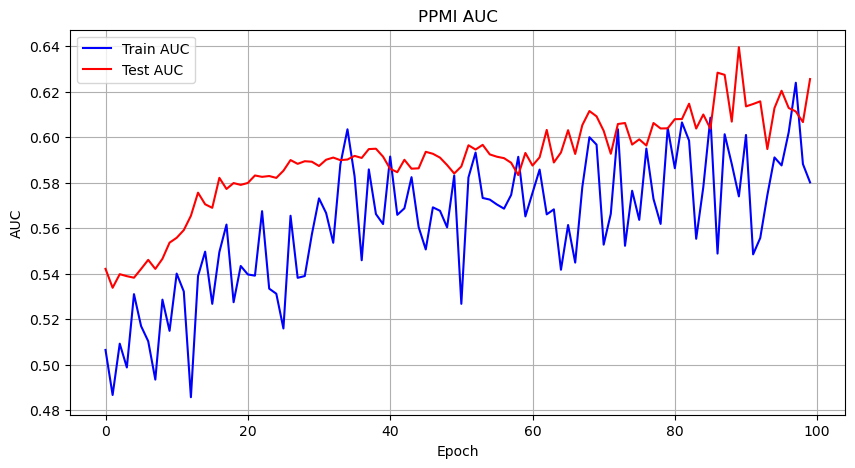

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_aucs)), train_aucs, label="Train AUC", color="blue")
plt.plot(range(len(test_aucs)), test_aucs, label="Test AUC", color="red")
plt.title("PPMI AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)
plt.show()

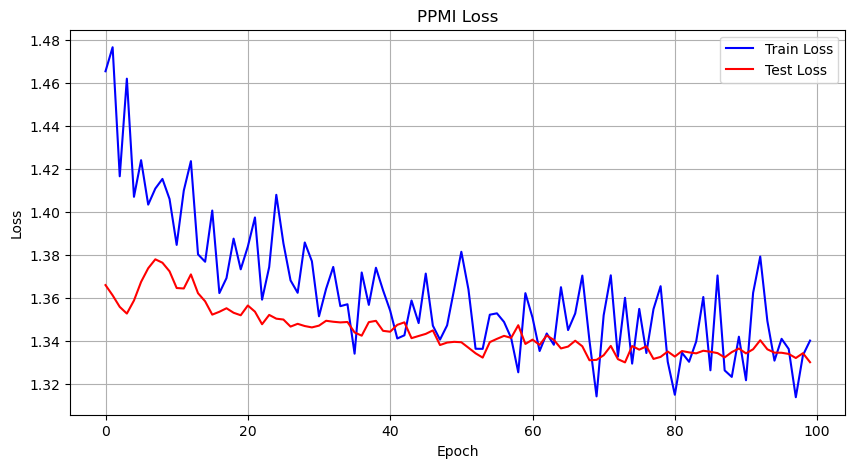

In [24]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_losses)), train_losses, label="Train Loss", color="blue")
plt.plot(range(len(test_losses)), test_losses, label="Test Loss", color="red")
plt.title("PPMI Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()